#spass 파일을 읽기 위해 라이브러리 설치
!pip install pyreadstat

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family']='Malgun Gothic'


In [148]:
df = pd.read_spss('content/koweps_hpc19_2024_beta1.sav')
row_data = df.copy()
df.tail()
#print(df['h19_g3','h19_g4','p1902_8aq1','h19_eco9'])

,h19_id,h19_ind,h19_sn,h19_merkey,h_new,h_new1,h19_cobf,p19_wsc,p19_wsl,p19_wgc,...,c1907_4aq19,c1907_4aq20,c1907_4aq21,c1907_4aq22,c1907_4aq23,h19_pers_income1,h19_pers_income2,h19_pers_income3,h19_pers_income4,h19_pers_income5
15417,12010.0,17.0,1.0,120101701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,12320.0,NaN,NaN,0.0,NaN
15418,12010.0,17.0,1.0,120101701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3120.0,NaN,0.0,NaN
15419,12010.0,17.0,1.0,120101701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
15420,12011.0,17.0,1.0,120111701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7200.0,-1800.0,0.0,NaN
15421,12011.0,17.0,1.0,120111701.0,0.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15422 entries, 0 to 15421
Columns: 1046 entries, h19_id to h19_pers_income5
dtypes: float64(1045), object(1)
memory usage: 123.1+ MB


In [150]:
df.columns #데이터프레임에 포함된 모든 컬럼명(변수명) 확인

Index(['h19_id', 'h19_ind', 'h19_sn', 'h19_merkey', 'h_new', 'h_new1',
       'h19_cobf', 'p19_wsc', 'p19_wsl', 'p19_wgc',
       ...
       'c1907_4aq19', 'c1907_4aq20', 'c1907_4aq21', 'c1907_4aq22',
       'c1907_4aq23', 'h19_pers_income1', 'h19_pers_income2',
       'h19_pers_income3', 'h19_pers_income4', 'h19_pers_income5'],
      dtype='object', length=1046)

In [151]:
#df.describe()

In [152]:
## 성별 출생년도 월평균임금 직업
print(df[['h19_g3','h19_g4','p1902_8aq1','h19_eco9']])



       h19_g3  h19_g4  p1902_8aq1  h19_eco9
0         2.0  1945.0         NaN       NaN
1         1.0  1948.0       183.0     942.0
2         1.0  1942.0         NaN     782.0
3         1.0  1962.0       270.0     855.0
4         2.0  1963.0        33.0     421.0
...       ...     ...         ...       ...
15417     1.0  1975.0      1010.0     222.0
15418     2.0  1976.0       260.0     313.0
15419     2.0  2009.0         NaN       NaN
15420     1.0  1964.0         NaN     248.0
15421     2.0  1964.0         NaN       NaN

[15422 rows x 4 columns]


In [153]:
# 주요 변수명을 보기 좋게 변경
data = df.rename(columns={
    'h19_g3':'sex'
    ,'h19_g4':'birth'
    ,'p1902_8aq1':'income'
    ,'h19_eco9':'job_code'
})
print(data)
data = data[['sex','birth','income','job_code']]


        h19_id  h19_ind  h19_sn   h19_merkey  h_new  h_new1  h19_cobf  \
0          2.0      1.0     1.0      20101.0    0.0     0.0       NaN   
1          3.0      1.0     1.0      30101.0    0.0     0.0       NaN   
2          4.0      1.0     1.0      40101.0    0.0     0.0       NaN   
3          6.0      1.0     1.0      60101.0    0.0     0.0       NaN   
4          6.0      1.0     1.0      60101.0    0.0     0.0       NaN   
...        ...      ...     ...          ...    ...     ...       ...   
15417  12010.0     17.0     1.0  120101701.0    0.0     1.0       NaN   
15418  12010.0     17.0     1.0  120101701.0    0.0     1.0       NaN   
15419  12010.0     17.0     1.0  120101701.0    0.0     1.0       NaN   
15420  12011.0     17.0     1.0  120111701.0    0.0     1.0       NaN   
15421  12011.0     17.0     1.0  120111701.0    0.0     1.0       NaN   

        p19_wsc   p19_wsl      p19_wgc  ...  c1907_4aq19  c1907_4aq20  \
0      0.266048  0.268809  1441.082985  ...       

In [154]:
data.describe()

,sex,birth,income,job_code
count,15422.000000,15422.000000,5501.000000,8015.000000
mean,1.552004,1969.943587,297.934921,590.945228
std,0.497304,24.171551,230.994026,269.377681
min,1.000000,1906.000000,0.000000,111.000000
25%,1.000000,1949.000000,144.000000,313.000000
50%,2.000000,1966.000000,257.000000,611.000000
75%,2.000000,1989.000000,393.000000,873.000000
max,2.000000,2023.000000,2097.000000,1009.000000


In [155]:
# 범주형 데이터 확인할 때
# 성별 변수에 어떤 값들이 있는지 확인
data['sex'].unique()

array([2., 1.])

In [156]:
# 성별의 결측치 갯수 확인
data['sex'].isna().sum()

np.int64(0)

In [157]:
# 성별 변수의 값별 빈도수 확인
data['sex'].value_counts()

sex
2.0    8513
1.0    6909
Name: count, dtype: int64

In [158]:
data['sex'] = np.where(data['sex']==1.0,'M','F')
print(data)

      sex   birth  income  job_code
0       F  1945.0     NaN       NaN
1       M  1948.0   183.0     942.0
2       M  1942.0     NaN     782.0
3       M  1962.0   270.0     855.0
4       F  1963.0    33.0     421.0
...    ..     ...     ...       ...
15417   M  1975.0  1010.0     222.0
15418   F  1976.0   260.0     313.0
15419   F  2009.0     NaN       NaN
15420   M  1964.0     NaN     248.0
15421   F  1964.0     NaN       NaN

[15422 rows x 4 columns]


In [159]:
data.head()

,sex,birth,income,job_code
0,F,1945.0,NaN,NaN
1,M,1948.0,183.0,942.0
2,M,1942.0,NaN,782.0
3,M,1962.0,270.0,855.0
4,F,1963.0,33.0,421.0


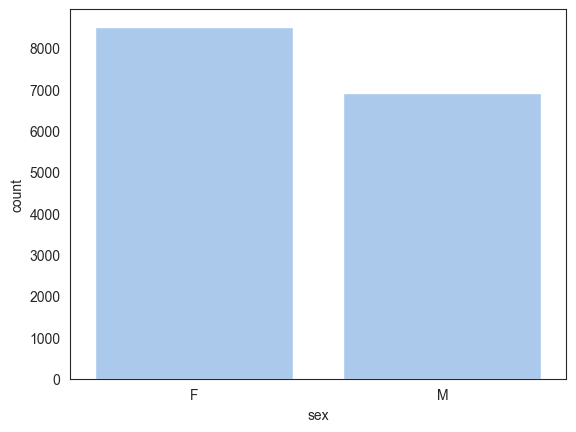

In [160]:
sns.set_style('white')
sns.set_palette('pastel')

sns.countplot(data=data,x='sex') # 분포 확인할 때 좋다
plt.show()

In [161]:
# 소득(월 평균 임금)의 기초 통계
data['income'].describe()

count    5501.000000
mean      297.934921
std       230.994026
min         0.000000
25%       144.000000
50%       257.000000
75%       393.000000
max      2097.000000
Name: income, dtype: float64

In [162]:
# 소득의 결측치 확인
data['income'].isnull().sum()

np.int64(9921)

<Axes: xlabel='income', ylabel='Count'>

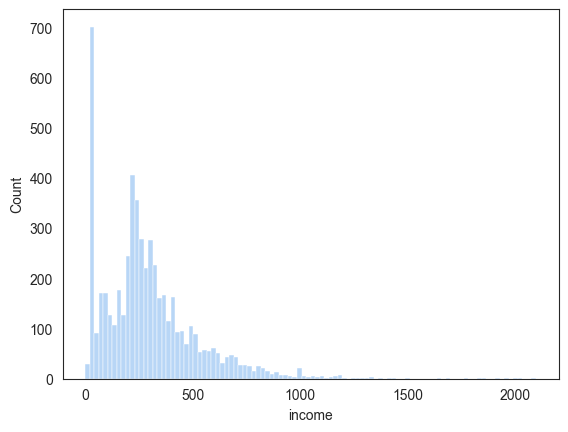

In [163]:
# 소득의 분포를 히스토그램으로 시각화
sns.histplot(data=data, x='income', bins=100)

c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


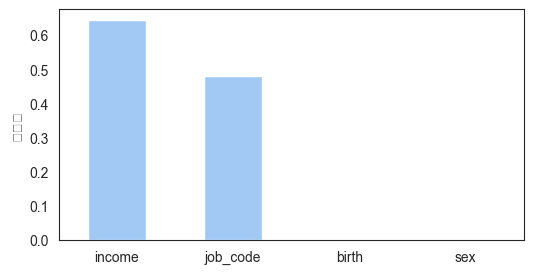

In [164]:
# 변수별 결측 비율
na_rate = data.isnull().mean().sort_values(ascending=False) # 각 컬럼의 결측값 비율 계산 후 내림차순

plt.figure(figsize=(6,3))
na_rate.plot(kind='bar')
plt.ylabel('결측률')
plt.xticks(rotation=0)
plt.show()

Text(0.5, 1.0, '성별별 소득 결측 비율')

c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 46301 (\N{HANGUL SYLLABLE DEUG}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\Playdata\data_analysis\data_venv\Li

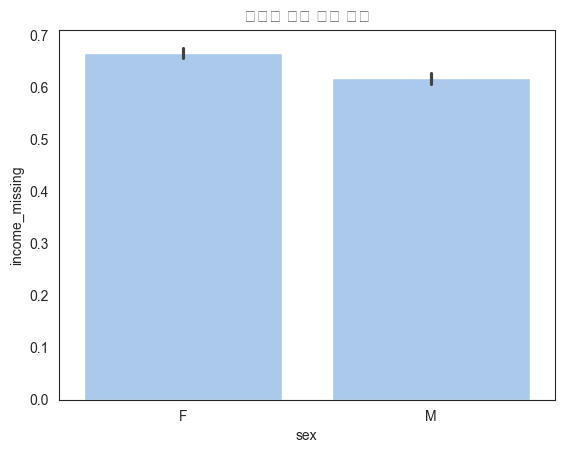

In [165]:
# 성별별 소득의 결측 비율
temp = data.assign(income_missing=data['income'].isnull()) # income 결측 여부를 True/False로 나타내서 temp에 저장=
sns.barplot(data=temp, x='sex',y="income_missing")
plt.title('성별별 소득 결측 비율')

In [166]:
# 성별 평균 소득 계산
sex_income = data.dropna(subset=['income']) # 소득에 결측치가 있는 행 제거
sex_income = sex_income.groupby('sex')['income'].mean() # 성별별 평균 소득 계산

sex_income

sex
F    211.099229
M    391.425066
Name: income, dtype: float64

<Axes: xlabel='sex', ylabel='income'>

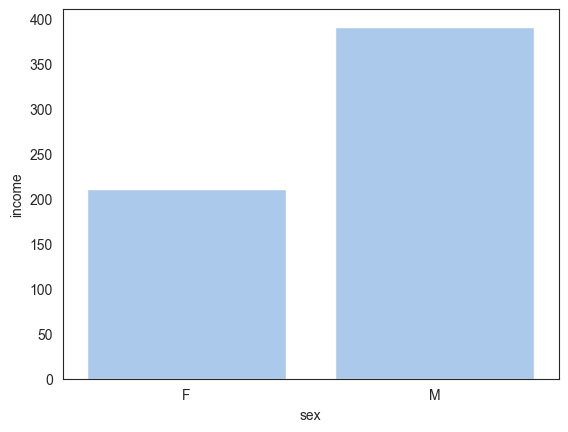

In [167]:
sns.barplot(sex_income)

Text(0.5, 1.0, '성별별 소득 이상치')

c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 46301 (\N{HANGUL SYLLABLE DEUG}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\Playdata\data_analysis\data_venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\Playdata\data_analysis\data_venv\Lib\si

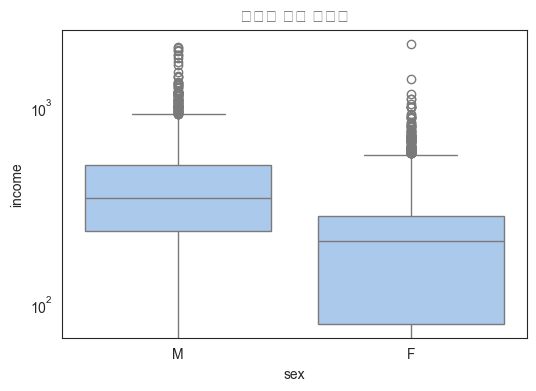

In [168]:
# 성별별 소득의 이상치 확인 (박스플롯)
temp = data.dropna(subset=['income'])

plt.figure(figsize=(6,4))
sns.boxplot(data=temp, x='sex', y='income')
plt.yscale('log')
plt.title('성별별 소득 이상치')

In [169]:
# 남성 소득을 여성 소득으로 나눈 비율 계산
sex_income['M'] / sex_income['F'] * 100


np.float64(185.42230999007086)

In [170]:
# T-Test를 통해 성별 소득 차이의 통계적 유의성 검정
import scipy.stats as stats

# 남성과 여성 데이터를 추출하고, 결측치 제거
sex_m = data[data['sex']=='M'].dropna()
sex_f = data[data['sex']=='F'].dropna()

stats.ttest_ind(sex_m['income'],sex_f['income'],equal_var=True) # 독립표본 t-검정 수행


TtestResult(statistic=np.float64(31.41661395534693), pvalue=np.float64(2.084390099769578e-199), df=np.float64(5499.0))

In [171]:
# 출생연도 변수의 통계 요약 정보
data['birth'].describe()

count    15422.000000
mean      1969.943587
std         24.171551
min       1906.000000
25%       1949.000000
50%       1966.000000
75%       1989.000000
max       2023.000000
Name: birth, dtype: float64

<Axes: xlabel='birth', ylabel='Count'>

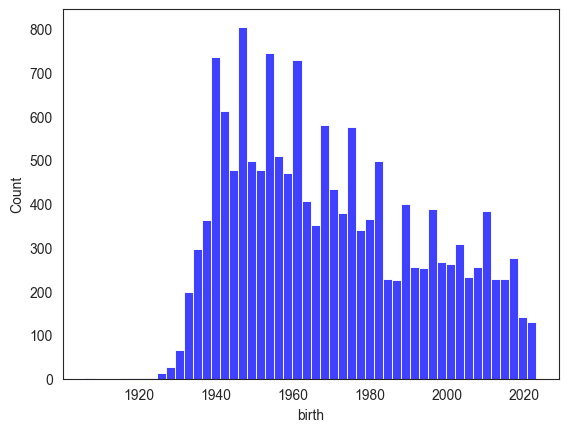

In [172]:
sns.histplot(data=data['birth'], color='blue', bins=50)

In [173]:
data['age'] = 2025 - data['birth']# 2025년 기준으로 나이 계산 (기준년도 - 출생년도)
data


,sex,birth,income,job_code,age
0,F,1945.0,NaN,NaN,80.0
1,M,1948.0,183.0,942.0,77.0
2,M,1942.0,NaN,782.0,83.0
3,M,1962.0,270.0,855.0,63.0
4,F,1963.0,33.0,421.0,62.0
...,...,...,...,...,...
15417,M,1975.0,1010.0,222.0,50.0
15418,F,1976.0,260.0,313.0,49.0
15419,F,2009.0,NaN,NaN,16.0
15420,M,1964.0,NaN,248.0,61.0


In [174]:
data['age'] = data['age'].astype('int')
data

,sex,birth,income,job_code,age
0,F,1945.0,NaN,NaN,80
1,M,1948.0,183.0,942.0,77
2,M,1942.0,NaN,782.0,83
3,M,1962.0,270.0,855.0,63
4,F,1963.0,33.0,421.0,62
...,...,...,...,...,...
15417,M,1975.0,1010.0,222.0,50
15418,F,1976.0,260.0,313.0,49
15419,F,2009.0,NaN,NaN,16
15420,M,1964.0,NaN,248.0,61


<Axes: xlabel='age'>

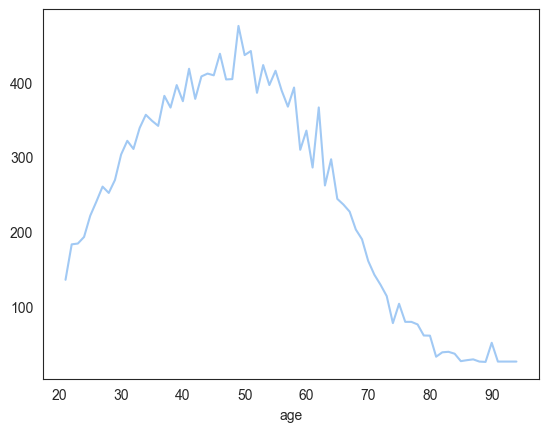

In [175]:
# 나이별 평등 소득 시각화

data_income = data.dropna(subset=['income']) # 소득의 결측치

# 나이별 평균 소득 계산
data_income = data_income.groupby('age')['income'].mean()
data_income.plot()

In [176]:
# 나이별 평균 소득이 가장 높은 나이
data_income.idxmax() # 가장 큰 값이 있는 index(나이로 groupby) 반환

np.int64(49)

In [177]:
data_income.sort_values(ascending=False) # 나이별 평균 소득을 내림차순 정렬


age
49    475.018349
51    441.511278
46    437.867257
50    436.088710
53    422.788136
         ...    
91     27.000000
93     27.000000
92     27.000000
94     27.000000
89     26.533333
Name: income, Length: 74, dtype: float64

<Axes: xlabel='agetype', ylabel='income'>

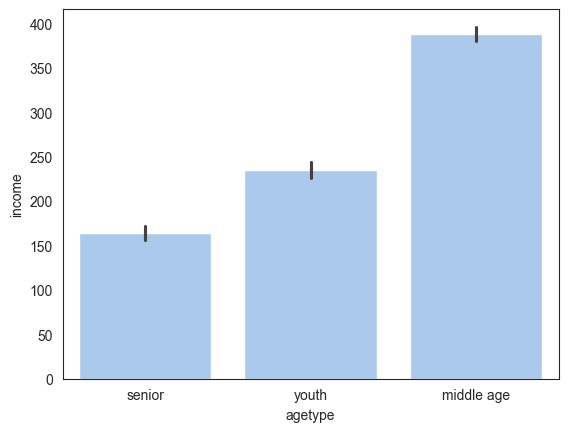

In [178]:
# 나이를 기준으로 세가지 연령대 범주 지정
data = data.assign(
    agetype = np.where(
        data['age']<30, 'youth',
        np.where(data['age']<60, 'middle age', 'senior')
    )
)

sns.barplot(data=data, x='agetype', y='income')

In [179]:
# 연령대별 평균 소득 계산
data.groupby('agetype')['income'].mean()

agetype
middle age    388.342483
senior        163.940803
youth         235.476891
Name: income, dtype: float64

In [180]:
# 연령대와 성별 조합으로 평균 소득 계산
data.groupby(['agetype','sex'])['income'].mean()


agetype     sex
middle age  F      288.949153
            M      470.311590
senior      F      110.974848
            M      246.579161
youth       F      229.501767
            M      244.238342
Name: income, dtype: float64

In [181]:
# 성별과 나이별 평균 소득 계산
# 소득 결측치 제거 후, 성별과 나이를 기준으로 그룹화하여 평균 소득 계산
age_sex = data.dropna(subset=['income']).groupby(['sex','age'],as_index=False)['income'].mean()

age_sex

,sex,age,income
0,F,21,117.909091
1,F,22,164.111111
2,F,23,163.363636
3,F,24,201.692308
4,F,25,218.131579
...,...,...,...
141,M,89,27.000000
142,M,90,30.000000
143,M,92,27.000000
144,M,93,27.000000


<Axes: xlabel='age', ylabel='income'>

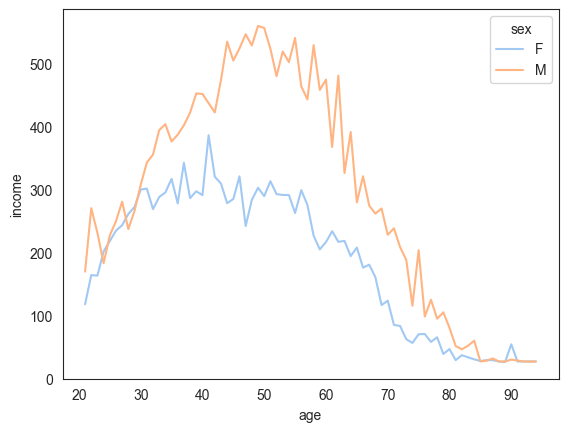

In [182]:
sns.lineplot(data=age_sex, x='age', y='income', hue='sex')

In [183]:
len(data['job_code'].unique()) # 직업 코드의 고유값 개수(unique함수로 중복 제거된 상태)



154

In [184]:
# 직업코드
job_name = pd.read_excel('content/(2024년 19차 한국복지패널조사) 조사설계서-가구용(beta1).xlsx',sheet_name='직종코드(2019 신분류)')
job_name = job_name.rename(columns={
    '소분류' : 'job_code',
    'Unnamed: 3' : 'job'
})
job_name = job_name[['job','job_code']] # 필요한 컬럼만 추출
job_name.count()

job         156
job_code    156
dtype: int64

In [185]:
# data(분석 데이터)와 job_name(직업별 매핑표)을 직업코드 기준으로 결합
job_df = data.merge(job_name,on='job_code',how='left')

job_df

,sex,birth,income,job_code,age,agetype,job
0,F,1945.0,NaN,NaN,80,senior,NaN
1,M,1948.0,183.0,942.0,77,senior,건물 관리원 및 검표원
2,M,1942.0,NaN,782.0,83,senior,건설관련기능종사자
3,M,1962.0,270.0,855.0,63,senior,금속기계 부품 조립원
4,F,1963.0,33.0,421.0,62,senior,돌봄 및 보건 서비스 종사자
...,...,...,...,...,...,...,...
15417,M,1975.0,1010.0,222.0,50,middle age,컴퓨터 시스템 및 소프트웨어 전문가
15418,F,1976.0,260.0,313.0,49,middle age,회계 및 경리 사무원
15419,F,2009.0,NaN,NaN,16,youth,NaN
15420,M,1964.0,NaN,248.0,61,senior,종교 관련 종사자


In [190]:
# 직업별 평균 소득 계산
job_income_mean = job_df.dropna(subset=['job','income']).groupby("job")['income'].mean()
job_income_mean

job
가사 및 육아 도우미                 99.566667
간호사                        342.000000
감정∙기술영업및중개관련종사자            472.625000
건물 관리원 및 검표원               219.780488
건설 및 광업 단순 종사자             298.063492
                              ...    
화학∙고무 및 플라스틱 제품 생산기 조작원    485.083333
화학공학 기술자 및 시험원             654.500000
환경∙청소 및 경비 관련 관리자          163.838710
환경공학∙가스·에너지 기술자 및 시험원      405.666667
회계 및 경리 사무원                344.072034
Name: income, Length: 152, dtype: float64

In [189]:
# 평균 소득 상위 10개 확인
job_income_mean.sort_values(ascending=False).head(10)

job_code
112.0     898.000000
241.0     862.500000
262.0     830.500000
221.0     784.200000
135.0     756.333333
132.0     748.437500
1001.0    717.250000
235.0     703.000000
121.0     681.428571
261.0     673.800000
Name: income, dtype: float64

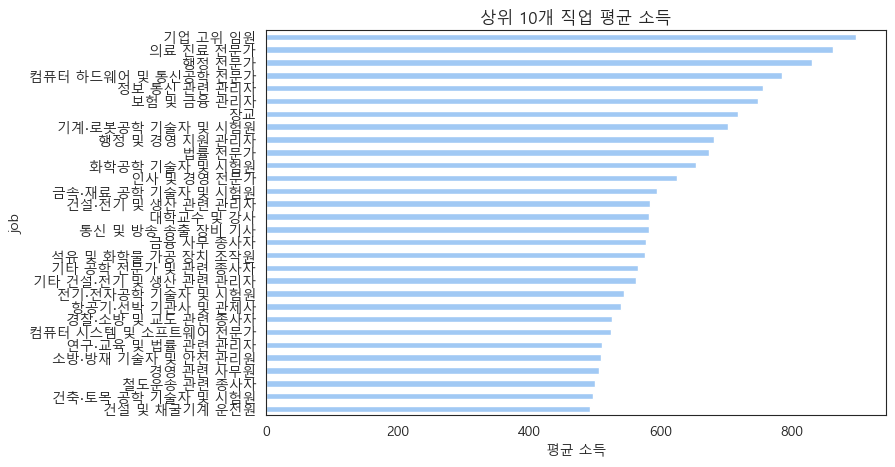

In [204]:
# 가로 막대 그래프 시각화 
# 평균 소득 상위 10개 직업 추출 후, 그래프에서 보기좋게 다시 오름차순 정렬
top10 = job_income_mean.sort_values(ascending=False).head(30).sort_values()
plt.figure(figsize=(8,5))
top10.plot(kind='barh')
plt.title('상위 10개 직업 평균 소득')
plt.xlabel('평균 소득')
plt.show()

In [199]:
# 평균 소득 하위 10개 직업 추출
job_income_mean.sort_values().head(10)


job
청소원 및 환경미화원                  78.167435
기타 서비스 관련 단순 종사자             97.510121
가사 및 육아 도우미                  99.566667
인문 및 사회과학 전문가               100.000000
기타 돌봄∙보건 및 개인 생활 서비스 종사자    109.413333
음식 관련 단순 종사자                135.043796
돌봄 및 보건 서비스 종사자             146.252066
환경∙청소 및 경비 관련 관리자           163.838710
판매 관련 단순 종사자                169.388889
학예사∙사서 및 기록물 관리사            184.500000
Name: income, dtype: float64

<Axes: ylabel='job'>

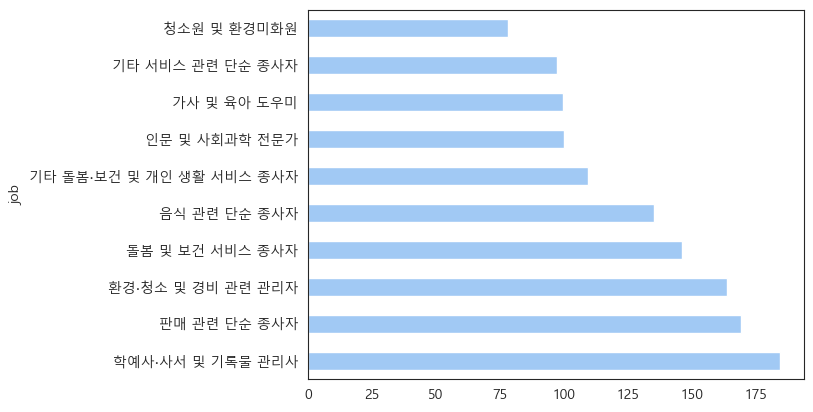

In [202]:
# 평균 소득 하위 10개 직업 가로 막대그래프로 시각화
botton10 = job_income_mean.sort_values().head(10).sort_values(ascending=False)

botton10.plot(kind='barh')